# Ebenhöh2014

[https://doi.org/10.1098/rstb.2013.0223](https://doi.org/10.1098/rstb.2013.0223)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from mxlpy import Model, Scipy, Simulator, cartesian_product, make_protocol, scan

from mxlmodels import get_ebenhoeh2014


def bdf_integrator(
    rhs: Model, y0: tuple[float, ...], jacobian=None, t0: float = 0.0
) -> Scipy:
    return Scipy(
        rhs=rhs, y0=y0, jacobian=jacobian, t0=t0, method="BDF", atol=1e-8, rtol=1e-8
    )

## Figure 2

### Simulation

In [58]:
m_dark = get_ebenhoeh2014()
m_dark.update_parameter("PPFD", 0)

s_dark = Simulator(m_dark, integrator=bdf_integrator)
s_dark.simulate_to_steady_state()

m_dark.update_variables(s_dark.get_result().unwrap_or_err().get_new_y0())

flash_t = 0.8
flash_ppfd = 5e4

period_t = 90

dark_ppfd = 0
light_ppfd = 100

protocol_normal = make_protocol(
    [(flash_t, {"PPFD": flash_ppfd}), (period_t - flash_t, {"PPFD": dark_ppfd})] * int(5*60/period_t) +
    [(flash_t, {"PPFD": flash_ppfd}), (period_t - flash_t, {"PPFD": light_ppfd})] * int(10*60/period_t) +
    [(flash_t, {"PPFD": flash_ppfd}), (period_t - flash_t, {"PPFD": dark_ppfd})] * int(1500/period_t)
)


O2_og = get_ebenhoeh2014().get_parameter_values()["O2 (dissolved)_lumen"]

protocol_anoxia = make_protocol(
    [(flash_t, {"PPFD": flash_ppfd, "O2 (dissolved)_lumen": 0}), (period_t - flash_t, {"PPFD": dark_ppfd, "O2 (dissolved)_lumen": 0})] * int(5*60/period_t) +
    [(flash_t, {"PPFD": flash_ppfd, "O2 (dissolved)_lumen": 0}), (period_t - flash_t, {"PPFD": light_ppfd, "O2 (dissolved)_lumen": 0})] * int(10*60/period_t) +
    [(flash_t, {"PPFD": flash_ppfd, "O2 (dissolved)_lumen": O2_og}), (period_t - flash_t, {"PPFD": dark_ppfd, "O2 (dissolved)_lumen": O2_og})] * int(1500/period_t)
)

res_fig2 = (
    Simulator(m_dark, integrator=bdf_integrator)
    .simulate_protocol(protocol_anoxia, time_points_per_step=40)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

In [16]:
15*60

900

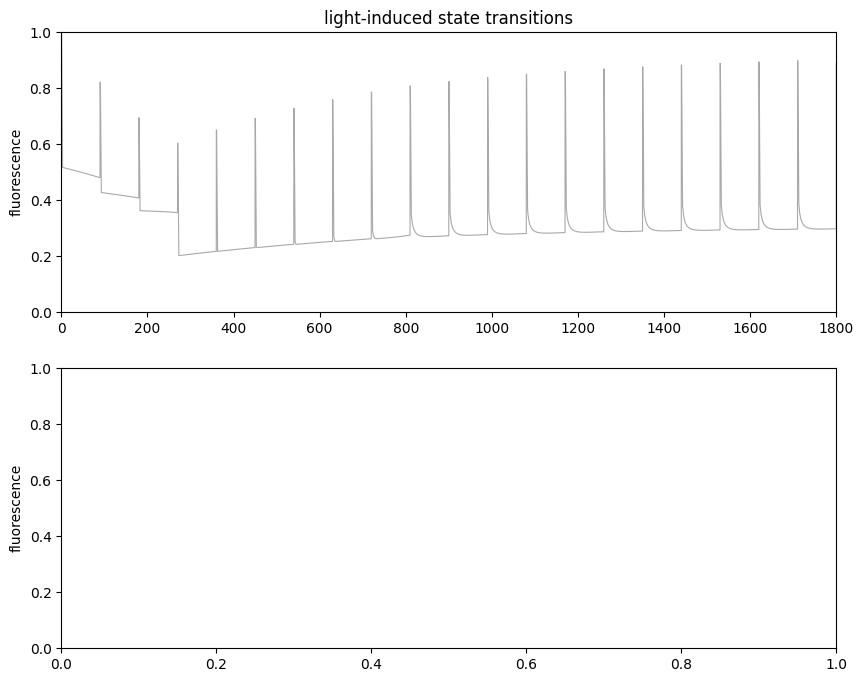

In [59]:
fig, axs = plt.subplots(figsize=(10, 8), nrows=2)

axs[0].plot(res_fig2.index, res_fig2["Fluo"] / res_fig2["Fluo"].max(), color="#a7a9ac", lw=0.8, label="Simulation")

axs[0].set_xlim(0, 1800)
axs[0].set_xticks(np.linspace(0, 1800, 10))
axs[0].set_title("light-induced state transitions")

for ax in axs:
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_ylabel("fluorescence")

plt.show()

## Fig 2b - Anoxia

In [11]:
m = get_ebenhoeh2014()
p0 = m.get_parameter_values()


T_max = 3200
T_on = 360
T_off = 1800
_t_ambient = 120

O2ext = p0["O2 (dissolved)_lumen"]
kNDH = p0["kf_ndh"]

sequence = []
t = 0.0
while t < T_max:
    anox = T_on < t < T_off
    O2 = 0.0 if anox else O2ext
    ndh = kNDH if anox else 0.0
    if abs(t % _t_ambient) < 1e-9:
        sequence.append((_t_flash, _i_flash, O2, ndh))
        t += _t_flash
    else:
        sequence.append((_t_ambient - _t_flash, _i_dark, O2, ndh))
        t += _t_ambient - _t_flash
dur = np.array([s[0] for s in sequence])
intensity = [s[1] for s in sequence]
O2 = [s[2] for s in sequence]
kf_ndh = [s[3] for s in sequence]
protocol = pd.DataFrame(
    {"PPFD": intensity, "O2 (dissolved)_lumen": O2, "kf_ndh": kf_ndh},
    index=pd.to_timedelta(np.cumsum(dur), unit="s"),
)

In [15]:
1800/60

30.0

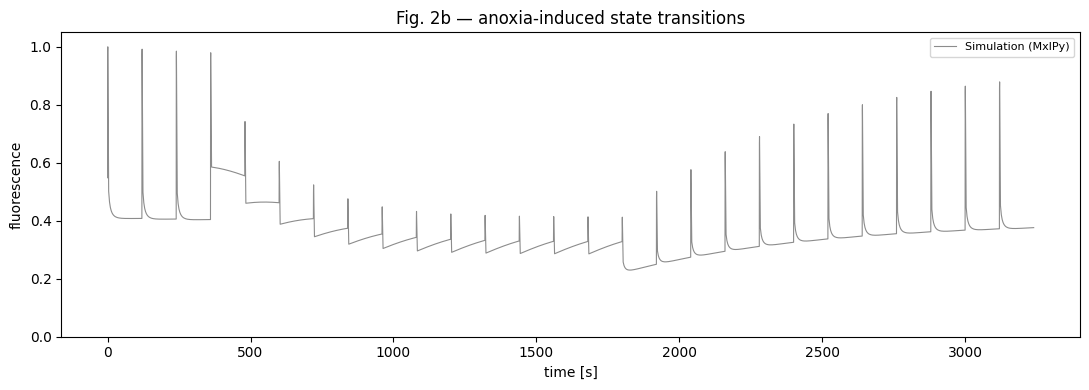

In [12]:
# anoxic state
T_max = 3200
T_on = 360
T_off = 1800
_t_ambient = 120

O2ext = p0["O2 (dissolved)_lumen"]
kNDH = p0["kf_ndh"]

sequence = []
t = 0.0
while t < T_max:
    anox = T_on < t < T_off
    O2 = 0.0 if anox else O2ext
    ndh = kNDH if anox else 0.0
    if abs(t % _t_ambient) < 1e-9:
        sequence.append((_t_flash, _i_flash, O2, ndh))
        t += _t_flash
    else:
        sequence.append((_t_ambient - _t_flash, _i_dark, O2, ndh))
        t += _t_ambient - _t_flash
dur = np.array([s[0] for s in sequence])
intensity = [s[1] for s in sequence]
O2 = [s[2] for s in sequence]
kf_ndh = [s[3] for s in sequence]
protocol = pd.DataFrame(
    {"PPFD": intensity, "O2 (dissolved)_lumen": O2, "kf_ndh": kf_ndh},
    index=pd.to_timedelta(np.cumsum(dur), unit="s"),
)

m.update_variables(
    {
        "Plastoquinone (oxidised)": p0["PQ_tot"],
        "Plastocyanine (oxidised)": 0.0202,
        "Ferredoxine (oxidised)": 5.0,
        "ATP": 0.0,
        "NADPH": 0.0,
        "Light-harvesting complex": 0.9,
    }
)

res = (
    Simulator(m, integrator=bdf_integrator)
    .simulate_protocol(protocol, time_points_per_step=40)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

flou = res["Fluo"].to_numpy()
norm_flou = flou / flou.max()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(res.index, norm_flou, color="0.55", lw=0.8, label="Simulation (MxlPy)")
ax.set(
    xlabel="time [s]",
    ylabel="fluorescence",
    title="Fig. 2b — anoxia-induced state transitions",
    ylim=(0, 1.05),
)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

In [ ]:
m = get_ebenhoeh2014()
# figure 3

antenna_crosssection = np.linspace(0, 1, 20)
ligth_intensity = np.linspace(25, 500, 20)

grid = cartesian_product(
    {
        "staticAntII": antenna_crosssection,
        "PPFD": ligth_intensity,
    }
)

m.update_parameters(
    {
        "staticAntI": 0.0,
        "kStt7": 0.0,
        "kPph1": 0.0,
    }
)
m.update_variable("Light-harvesting complex", 0.0)


s = scan.steady_state(m, to_scan=grid, integrator=bdf_integrator)

reduced_PQ = (
    s.variables["PQ_red/tot"]
    .unstack("staticAntII")  # Zeilen=PPFD, Spalten=staticAntII
    .reindex(index=ligth_intensity, columns=antenna_crosssection)
    .to_numpy()
)

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection="3d")

X, Y = np.meshgrid(antenna_crosssection, ligth_intensity)
surf = ax.plot_surface(
    X,
    Y,
    reduced_PQ,
    cmap=cm.jet,
    vmin=0,
    vmax=1,
    rstride=1,
    cstride=1,
    edgecolor="k",
    linewidth=0.2,
    antialiased=True,
)
ax.set_xlabel("relativer PSII-Antennenquerschnitt")
ax.set_ylabel("Lichtintensität [µE m⁻² s⁻¹]")
ax.set_zlabel("reduzierter Anteil des PQ-Pools")
ax.set_title("Fig. 3 — stationärer PQ-Redoxzustand")
ax.set_zlim(0, 1)
ax.view_init(elev=22, azim=-128)
fig.colorbar(surf, ax=ax, shrink=0.6, label="PQ red / PQ tot")
fig.tight_layout()
plt.show()

In [ ]:
cross_sections = np.linspace(0, 1, 20)  # = LHC-Werte (x-Achse)
light_levels = np.linspace(25, 500, 20)

m = get_ebenhoeh2014()
# staticAntI bleibt beim Default 0.2 -- NICHT auf 0 setzen!
m.update_parameters(
    {
        "kStt7": 0.0,  # State transitions einfrieren
        "kPph1": 0.0,
    }
)
# staticAntII bleibt 0 (Default)

grid = cartesian_product(
    {
        "Light-harvesting complex": cross_sections,  # LHC fest vorgeben, das ist die x-Achse
        "PPFD": light_levels,
    }
)

ss = scan.steady_state(m, to_scan=grid, integrator=bdf_integrator)

reduced_PQ = (
    ss.variables["PQ_red/tot"]
    .unstack("Light-harvesting complex")
    .reindex(index=light_levels, columns=cross_sections)
    .to_numpy()
)

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection="3d")

X, Y = np.meshgrid(antenna_crosssection, ligth_intensity)
surf = ax.plot_surface(
    X,
    Y,
    reduced_PQ,
    cmap=cm.jet,
    vmin=0,
    vmax=1,
    rstride=1,
    cstride=1,
    edgecolor="k",
    linewidth=0.2,
    antialiased=True,
)
ax.set_xlabel("relativer PSII-Antennenquerschnitt")
ax.set_ylabel("Lichtintensität [µE m⁻² s⁻¹]")
ax.set_zlabel("reduzierter Anteil des PQ-Pools")
ax.set_title("Fig. 3 — stationärer PQ-Redoxzustand")
ax.set_zlim(0, 1)
ax.view_init(elev=22, azim=-128)
fig.colorbar(surf, ax=ax, shrink=0.6, label="PQ red / PQ tot")
fig.tight_layout()
plt.show()